# MG Boost Emulator Demo

This notebook demonstrates how to use the MG Boost Emulator to compute
the modified gravity boost to the matter power spectrum.

The emulator combines:
- A neural network (linear regime)
- A Gaussian Process (nonlinear regime)
- Smooth stitching across scales

In [2]:
import numpy as np
import matplotlib.pyplot as plt


import sys
import os

sys.path.append(os.path.abspath(".."))

from emulator import MGEmulator



## Define Cosmology and load emulator

In [3]:
cosmo = {
    "Omega_m": 0.31,
    "Omega_b": 0.049,
    "h": 0.67,
    "n_s": 0.96,
    "A_s": 2.1e-9
}

mu = 1.05
eta = 1.0
bin_index = 2



In [4]:
zs = [0.0, 0.5, 1.0]

emu = MGEmulator(model_dir="../models")

k, boost = emu.predict_boost(
    cosmo,
    mu=mu,
    eta=eta,
    bin_index=bin_index,
    zs=zs
)

/home/sankarshana/git_repos/binned_MG_emulator/emulator/linear_nn.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=devic

## Plot Results

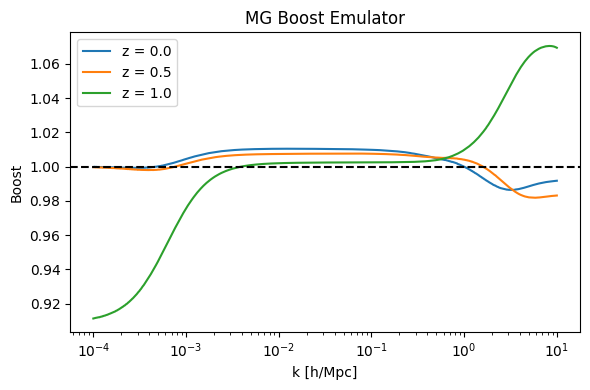

In [5]:
plt.figure(figsize=(6,4))

for i, z in enumerate(zs):
    plt.semilogx(k, boost[i], label=f"z = {z}")

plt.axhline(1.0, linestyle="--", color="black")

plt.xlabel("k [h/Mpc]")
plt.ylabel("Boost")
plt.title("MG Boost Emulator")

plt.legend()
plt.tight_layout()
plt.show()

## Plot $P(k)$ for different $\mu$ 

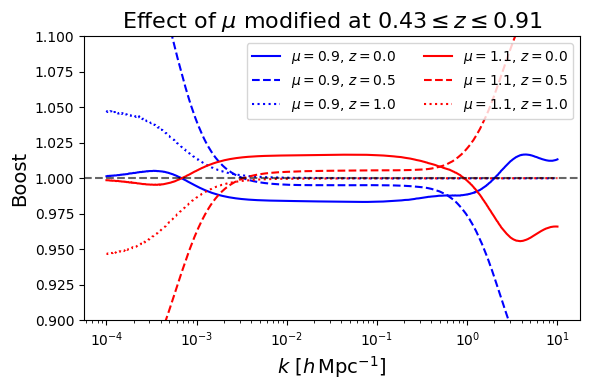

In [ ]:
mus = [0.9, 1.1]  # only the two you want

colors = {
    0.9: "blue",
    1.1: "red"
}

linestyles = {
    0.0: "-",
    0.5: "--",
    1.0: ":"
}

zs = [0.0, 0.5, 1.0]

plt.figure(figsize=(6,4))

for m in mus:

    k, boost = emu.predict_boost(
        cosmo,
        mu=m,
        eta=1.0,
        bin_index=1,
        zs=zs
    )

    for i, z in enumerate(zs):
        plt.semilogx(
            k,
            boost[i],
            color=colors[m],
            linestyle=linestyles[z],
            label=rf"$\mu={m},\, z={z}$"
        )

plt.axhline(1.0, linestyle="--", color="black", alpha=0.6)

plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=14)
plt.ylabel("Boost", fontsize=14)
plt.title(r"Effect of $\mu$ modified at $0.43 \leq z \leq 0.91$", fontsize=16)

plt.ylim(0.9, 1.1)

plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.savefig("../figures/boost_plot.png", dpi=300)
plt.show()